In [5]:
import pandas as pd

In [6]:
pd.__version__

'2.3.3'

In [4]:
!pip install pyarrow

In [33]:
import pandas as pd
import urllib.request
import os

# Create a folder to store the data
os.makedirs('data', exist_ok=True)

# Define the list of URLs for the datasets you want
urls = [
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-01.parquet",
    "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-02.parquet"
]

# Loop through each URL and download it
for url in urls:
    # This automatically grabs the file name from the end of the link
    file_name = url.split('/')[-1]
    file_path = f"data/{file_name}"
    
    print(f"Downloading {file_name}...")
    urllib.request.urlretrieve(url, file_path)
    print(f"Download complete: {file_name}\n")

print("All datasets downloaded successfully!")

# Load and test just the green one to make sure Pandas is working
df = pd.read_parquet("data/green_tripdata_2023-01.parquet")
df.head()

Download complete: green_tripdata_2023-01.parquet



Download complete: green_tripdata_2023-02.parquet

All datasets downloaded successfully!


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,1.0,0.5,4.03,0.0,None,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,1.0,0.5,2.64,0.0,None,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.2,1.0,0.5,1.94,0.0,None,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,0.5,1.5,1.70,0.0,None,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,0.5,1.5,0.00,0.0,None,1.0,8.00,1.0,1.0,0.00


In [ ]:
# df[df.trip_type == 2]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
16,1,2023-01-01 00:10:45,2023-01-01 00:19:37,N,5.0,83,129,1.0,1.30,15.0,0.0,0.0,0.00,0.00,None,0.0,15.00,1.0,2.0,0.00
32,2,2023-01-01 00:40:58,2023-01-01 01:04:32,N,5.0,66,164,4.0,6.78,60.0,0.0,0.0,12.61,0.00,None,0.3,75.66,1.0,2.0,2.75
43,2,2023-01-01 00:16:10,2023-01-01 00:54:55,N,5.0,66,48,3.0,6.19,75.0,0.0,0.0,0.00,0.00,None,0.3,78.05,2.0,2.0,2.75
55,2,2023-01-01 00:39:52,2023-01-01 00:48:54,N,5.0,129,226,1.0,2.08,15.0,0.0,0.0,0.00,0.00,None,1.0,16.00,1.0,2.0,0.00
98,2,2023-01-01 00:57:51,2023-01-01 01:07:05,N,5.0,260,74,2.0,5.34,52.0,0.0,0.0,0.00,6.55,None,1.0,59.55,1.0,2.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63833,2,2023-01-31 22:43:19,2023-01-31 22:46:09,N,5.0,130,130,1.0,0.00,10.0,0.0,0.0,0.00,0.00,None,1.0,11.00,2.0,2.0,0.00
63838,2,2023-01-31 22:40:51,2023-01-31 22:41:02,N,5.0,95,95,1.0,0.08,55.0,0.0,0.0,4.00,0.00,None,1.0,60.00,1.0,2.0,0.00
63868,2,2023-01-31 23:44:44,2023-01-31 23:45:15,N,5.0,264,264,1.0,0.00,-10.0,0.0,0.0,0.00,0.00,None,-1.0,-11.00,4.0,2.0,0.00
63869,2,2023-01-31 23:44:44,2023-01-31 23:45:15,N,5.0,264,264,1.0,0.00,10.0,0.0,0.0,0.00,0.00,None,1.0,11.00,4.0,2.0,0.00


In [34]:
# If you find an error convert the datetime columns correctly using pd.to_datetime()

# df.lpep_dropoff_datetime - df.lpep_pickup_datetime
# create a duration column
df["duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

In [35]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,0.5,4.03,0.0,None,1.0,24.18,1.0,1.0,2.75,0 days 00:11:01
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,0.5,2.64,0.0,None,1.0,15.84,1.0,1.0,0.00,0 days 00:06:46
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,...,0.5,1.94,0.0,None,1.0,11.64,1.0,1.0,0.00,0 days 00:06:20
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,1.5,1.70,0.0,None,1.0,10.20,1.0,1.0,0.00,0 days 00:05:49
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,1.5,0.00,0.0,None,1.0,8.00,1.0,1.0,0.00,0 days 00:05:58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,None,NaN,49,62,NaN,4070.82,15.70,...,0.0,0.00,0.0,None,1.0,16.70,NaN,NaN,NaN,0 days 00:13:00
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,None,NaN,10,205,NaN,2.14,4.41,...,0.0,0.00,0.0,None,1.0,5.41,NaN,NaN,NaN,0 days 00:08:00
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,None,NaN,66,37,NaN,3.44,16.53,...,0.0,3.51,0.0,None,1.0,21.04,NaN,NaN,NaN,0 days 00:16:00
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,None,NaN,225,189,NaN,3.03,14.98,...,0.0,3.20,0.0,None,1.0,19.18,NaN,NaN,NaN,0 days 00:18:00


In [39]:
df.duration = df.duration.apply(lambda td: td.total_seconds()/60)

In [40]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,0.5,4.03,0.0,None,1.0,24.18,1.0,1.0,2.75,11.016667
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,0.5,2.64,0.0,None,1.0,15.84,1.0,1.0,0.00,6.766667
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,...,0.5,1.94,0.0,None,1.0,11.64,1.0,1.0,0.00,6.333333
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,1.5,1.70,0.0,None,1.0,10.20,1.0,1.0,0.00,5.816667
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,1.5,0.00,0.0,None,1.0,8.00,1.0,1.0,0.00,5.966667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,None,NaN,49,62,NaN,4070.82,15.70,...,0.0,0.00,0.0,None,1.0,16.70,NaN,NaN,NaN,13.000000
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,None,NaN,10,205,NaN,2.14,4.41,...,0.0,0.00,0.0,None,1.0,5.41,NaN,NaN,NaN,8.000000
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,None,NaN,66,37,NaN,3.44,16.53,...,0.0,3.51,0.0,None,1.0,21.04,NaN,NaN,NaN,16.000000
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,None,NaN,225,189,NaN,3.03,14.98,...,0.0,3.20,0.0,None,1.0,19.18,NaN,NaN,NaN,18.000000


In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_15617/3426635498.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.duration)


<Axes: xlabel='duration', ylabel='Density'>

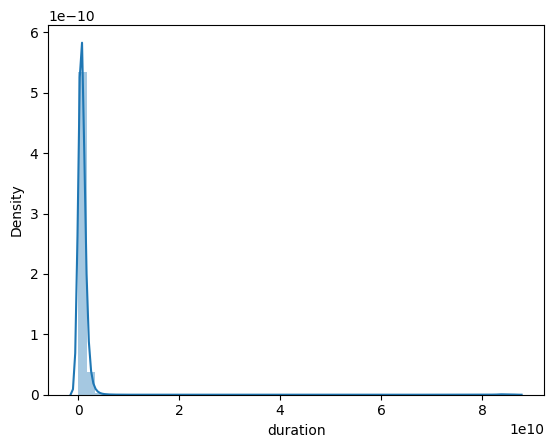

In [37]:
sns.distplot(df.duration)

In [42]:
df.duration.describe(percentiles=[0.95,0.98,0.99])

count    68211.000000
mean        18.097271
std         74.925631
min          0.000000
50%         11.400000
95%         33.266667
98%         45.616667
99%         58.115000
max       1439.883333
Name: duration, dtype: float64

In [43]:
# (df.duration >= 1) & (df.duration <= 60)
((df.duration >= 1) & (df.duration <= 60)).mean()

np.float64(0.9667942120772309)

In [44]:
categorical = ["PULocationID","DOLocationID"]
numerical = ["trip_distance"]

In [51]:
# df[categorical].dtypes
# Tuning
# df[categorical].astype(str).dtypes
df[categorical]=df[categorical].astype(str)


In [52]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,0.5,4.03,0.0,None,1.0,24.18,1.0,1.0,2.75,11.016667
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,0.5,2.64,0.0,None,1.0,15.84,1.0,1.0,0.00,6.766667
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,...,0.5,1.94,0.0,None,1.0,11.64,1.0,1.0,0.00,6.333333
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,1.5,1.70,0.0,None,1.0,10.20,1.0,1.0,0.00,5.816667
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,1.5,0.00,0.0,None,1.0,8.00,1.0,1.0,0.00,5.966667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,None,NaN,49,62,NaN,4070.82,15.70,...,0.0,0.00,0.0,None,1.0,16.70,NaN,NaN,NaN,13.000000
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,None,NaN,10,205,NaN,2.14,4.41,...,0.0,0.00,0.0,None,1.0,5.41,NaN,NaN,NaN,8.000000
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,None,NaN,66,37,NaN,3.44,16.53,...,0.0,3.51,0.0,None,1.0,21.04,NaN,NaN,NaN,16.000000
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,None,NaN,225,189,NaN,3.03,14.98,...,0.0,3.20,0.0,None,1.0,19.18,NaN,NaN,NaN,18.000000


In [53]:
from sklearn.feature_extraction import DictVectorizer

In [68]:
# df[categorical+numerical].iloc[:10].to_dict(orient="records")
train_dicts = df[categorical+numerical].to_dict(orient="records")

In [69]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [70]:
X_train

<68211x476 sparse matrix of type '<class 'numpy.float64'>'
	with 204633 stored elements in Compressed Sparse Row format>

In [71]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=11',
 'DOLocationID=111',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',
 'DOLocationID=146',
 'DOLocationID=147',

In [72]:
target = "duration"
y_train = df[target].values

In [73]:
y_train

array([11.01666667,  6.76666667,  6.33333333, ..., 16.        ,
       18.        , 16.        ])

In [75]:
from sklearn.linear_model import LinearRegression

In [76]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [77]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (68211, 476)
y_train shape: (68211,)


In [78]:
y_pred = lr.predict(X_train)

/tmp/ipykernel_15617/2943976952.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label="prediction")
/tmp/ipykernel_15617/2943976952.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label="actual")


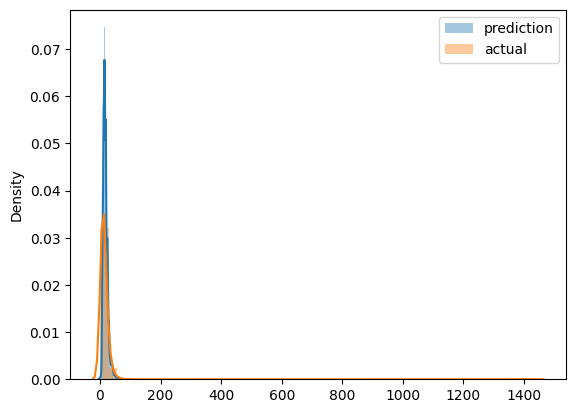

In [81]:
sns.distplot(y_pred, label="prediction")
sns.distplot(y_train, label="actual")
plt.legend()

In [82]:
from sklearn.metrics import mean_squared_error

In [87]:
import numpy as np
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

In [89]:
rmse

np.float64(74.50020859598766)

In [93]:
df_val = pd.read_parquet("data/green_tripdata_2023-02.parquet")
val_dicts = df_val[categorical+numerical].to_dict(orient="records")
X_val = dv.transform(val_dicts)

In [97]:
df_val["duration"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df_val.duration = df_val.duration.apply(lambda td: td.total_seconds()/60)
y_val = df_val[target].values

In [101]:
y_pred = lr.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
rmse


np.float64(77.01322817394548)

In [102]:
from sklearn.linear_model import Lasso, Ridge

In [106]:
# lr = Lasso(alpha=1)
lr = Ridge(alpha=0.1)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
rmse


np.float64(77.09414551029464)